# Compute time of entry and plot the comaparision among various networks
1. Import necessary requirements  
2. Load node community data  
3. Compute Time of Entry of nodes based on first time they enter the main cluster
4. Arrange nodes by their communities and plot them  
5. Use Avinash color scheme for communities as well as different colors for plots


#### 1. Import necessary requirements

In [3]:
from tes.analysis import AnalysisFunc
from tes.data_ingestion import DataRead

from pathlib import Path
import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Make objects

In [4]:
analyse=AnalysisFunc()
reader = DataRead()

#### Compute Time of Entry of nodes based on first time they enter the main cluster

Defining function for finding average TOE for given node community data

- Takes each node
- Calculates time when it first enters the main cluster
- Take median time spent for respective number of transitions

In [5]:
def avg_toe(df): 
    i=0
    f=5000
    # df=df_r_fn 
    toe=[]
    while f < df.shape[0]:
        mc=analyse.compute_main_cluster(df.iloc[i:f,:])
        t=analyse.compute_toe(df.iloc[i:f,:],mc)
        toe.append(t)
        i=f
        f+=5000
    # can use mean or median accordingly
    col_mean = np.median(np.array(toe),axis=0)
    return col_mean

In [7]:
FN_folder = Path('../../data/raw/FN/')
ENTI_folder = Path('../../data/raw/ENTI/')
ORBI_folder = Path('../../data/raw/ORBI/')
PERI_folder = Path('../../data/raw/PERI/')
PIR_folder = Path('../../data/raw/PIR/')
RE_folder = Path('../../data/raw/RE/')
BLA_folder= Path('../../data/raw/BLA')
files=[]
folders=[FN_folder,ENTI_folder,ORBI_folder,PERI_folder,PIR_folder,RE_folder,BLA_folder]
label=['FN','ENTI','ORBI','PERI','PIR','RE','BLA']
for folder in folders:
    file=glob.glob(str(folder / "nc_200.bz2"))
    files.append(file)

print(files)
toe=[]
for f in files: 
    df_nc = pd.read_pickle(f[0], compression="bz2")
    df_r = df_nc.reset_index(drop=True)
    mean_toe=avg_toe(df_r)
    toe.append(mean_toe)

# Sorting by communities
desired_order=list(reader.get_communities()['des_order'])
df_toe=pd.DataFrame(toe,index=label).T

# very powerful, whenever you concat any node data to community map, it automatically arranges in that order
toe_plot_data=pd.concat([reader.get_communities()['comm_map'].to_frame(),df_toe],axis=1)

# setting data for plotting
toe_plot_data.columns=['community', 'FN', 'ENTI', 'ORBI', 'PERI', 'PIR', 'RE','BLA']


[['../../data/raw/FN/nc_200.bz2'], ['../../data/raw/ENTI/nc_200.bz2'], ['../../data/raw/ORBI/nc_200.bz2'], ['../../data/raw/PERI/nc_200.bz2'], ['../../data/raw/PIR/nc_200.bz2'], ['../../data/raw/RE/nc_200.bz2'], ['../../data/raw/BLA/nc_200.bz2']]


## Plot time of entry for comparision with full network

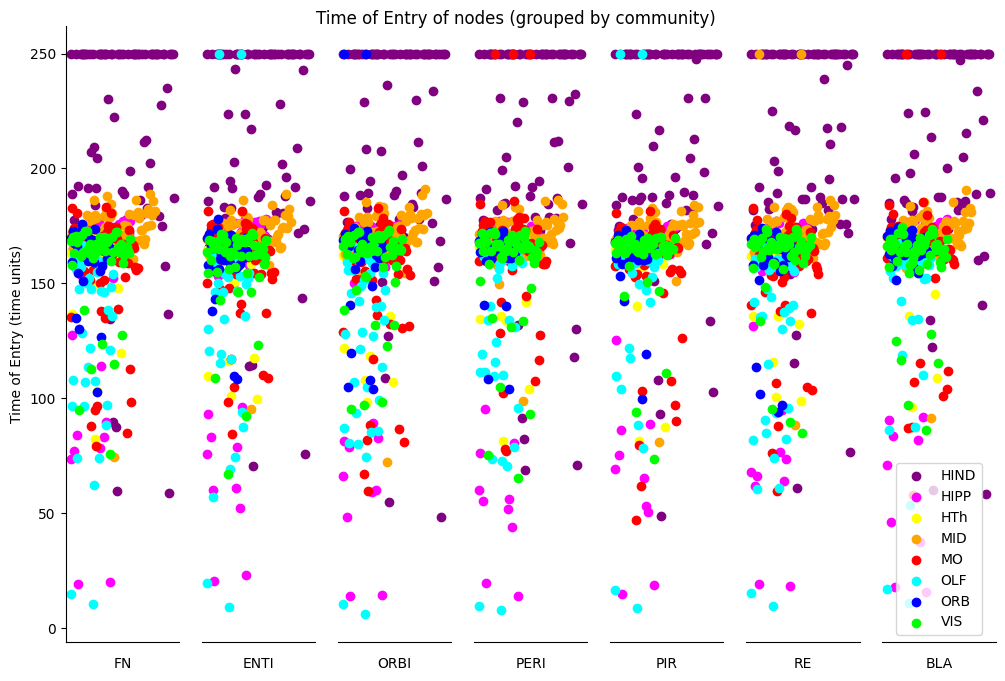

In [8]:
# getting communities data for x axis plot 
l=reader.get_communities()['comm_val']
l=l.to_dict()


comm=['MO', 'VIS', 'ORB', 'HTh', 'OLF', 'HIPP', 'MID', 'HIND']

node_c_avi =  ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]

fig,ax=plt.subplots(1,7,sharex=True,sharey=True, figsize=(12,8))


node_c_nim = ['#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080']
col = dict(zip(comm,node_c_nim))
grouped=toe_plot_data.groupby('community')
for community, group in grouped:
    ax[0].scatter(range(0,l[community]),group['FN']*0.05,color=col[community],label=community)
    ax[0].set_ylabel('Time of Entry (time units)')
    #ax[0].spines[["left", "right", "top", "bottom"]].set_visible(False)
    ax[0].set_xticks([50])
    ax[0].set_xticklabels([])
    ax[0].set_xlabel('FN')
    #ax[0].tick_params(axis="both", which="both", length=0)
    
    ax[1].scatter(range(0,l[community]),group['ENTI']*0.05,color=col[community],label=community)
    ax[1].set_xticks([50])
    ax[1].set_xticklabels([])
    ax[1].set_xlabel('ENTI')
    
    ax[2].scatter(range(0,l[community]),group['ORBI']*0.05,color=col[community],label=community)
    ax[2].set_xticks([50])
    ax[2].set_xticklabels([])
    ax[2].set_xlabel('ORBI')
    
    ax[3].scatter(range(0,l[community]),group['PERI']*0.05,color=col[community],label=community)
    ax[3].set_xticks([50])
    ax[3].set_xticklabels([])
    ax[3].set_xlabel('PERI')
    
    ax[4].scatter(range(0,l[community]),group['PIR']*0.05,color=col[community],label=community)
    ax[4].set_xticks([50])
    ax[4].set_xticklabels([])
    ax[4].set_xlabel('PIR')
    
    ax[5].scatter(range(0,l[community]),group['RE']*0.05,color=col[community],label=community)
    ax[5].set_xticks([50])
    ax[5].set_xticklabels([])
    ax[5].set_xlabel('RE')
    
    ax[6].scatter(range(0,l[community]),group['BLA']*0.05,color=col[community],label=community)
    ax[6].set_xticks([50])
    ax[6].set_xticklabels([])
    ax[6].set_xlabel('BLA')


# Remove outlines: Remove top/right spines from each subplot and hide most of the x-axis spines
for i, a in enumerate(ax):
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    
    # Hide the bottom spine for all subplots except the first one:
    if i != 0:
        a.spines['bottom'].set_visible(False)
        a.tick_params(bottom=False)  # Remove tick marks on the x-axis
        a.spines['left'].set_visible(False)
        a.tick_params(left=False) 
    else:
        a.spines['bottom'].set_visible(True)
        a.tick_params(bottom=True)
    
    # Ensure the left spine (y-axis) is visible:
    #a.spines['left'].set_visible(True)
    a.spines['bottom'].set_visible(True)
    a.tick_params(bottom=False)



plt.legend()
plt.suptitle('Time of Entry of nodes (grouped by community)',x=0.5,y=0.9)
plt.show()